# CSI4142 - Fundamentals of Data Science
# Assignment 3: Predictive Analysis

**Group number:** 77

**Student 1:** Peter Bou-Farah - 300295193  
**Student 2:** Martin Patrouchev - 300286634

### Work Split
- **Peter Bou-Farah:** Dataset 1 - Car Price Prediction (linear regression, outlier detection, feature engineering, empirical study)
- **Martin Patrouchev:** Dataset 2 - Telco Customer Churn (decision tree, outlier detection, feature engineering, empirical study)

---
# DATASET 1: Car Price Prediction (Regression)
---

## 1. Dataset Description

### Overview
- **Dataset Name:** Vehicle Dataset from CarDekho
- **Author:** Nehal Birla
- **Source:** [Kaggle](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho) | [GitHub](https://github.com/peter-bf/CSI4142/blob/master/A3/Car%20details%20v3.csv)
- **Purpose:** This dataset contains information about used cars listed on CarDekho, an Indian auto platform. It was compiled for price prediction tasks and contains details like manufacturing year, kilometers driven, fuel type, and engine specifications.

### Shape
- **Rows:** 8,128 (6,926 after removing duplicates)
- **Columns:** 13

### Features Description

| Feature | Type | Description |
|---------|------|-------------|
| name | Text | Full name of the car (brand + model + variant) |
| year | Numerical | Year the car was manufactured (1983-2020) |
| selling_price | Numerical (Target) | Listed selling price in Indian Rupees |
| km_driven | Numerical | Total kilometers driven by the car |
| fuel | Categorical | Fuel type: Diesel, Petrol, CNG, or LPG |
| seller_type | Categorical | Type of seller: Individual, Dealer, or Trustmark Dealer |
| transmission | Categorical | Gearbox type: Manual or Automatic |
| owner | Categorical | Ownership history: First, Second, Third, or Fourth & Above Owner |
| mileage | Text (Numerical) | Fuel efficiency in kmpl or km/kg (stored as string with units) |
| engine | Text (Numerical) | Engine displacement in CC (stored as string with units) |
| max_power | Text (Numerical) | Maximum power output in bhp (stored as string with units) |
| torque | Text | Maximum torque (inconsistent format, dropped during cleaning) |
| seats | Numerical | Number of seats in the car |

## 2. Setup and Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
warnings.filterwarnings('ignore')

## 3. Loading Dataset 1

In [25]:
df_original = pd.read_csv("https://raw.githubusercontent.com/peter-bf/CSI4142/master/A3/Car%20details%20v3.csv")

df = df_original.copy()

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (8128, 13)

First 5 rows:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [26]:
print("Dataset Info:")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "=" * 50)
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


Missing Values:
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


---
## 4. Data Cleaning

In this section, we clean the dataset by handling duplicates, parsing string-encoded numerical columns, and imputing missing values.

---

### 4.1 Removing Duplicates

The dataset contains exact duplicate rows that would bias the model. We identify and remove them.

In [27]:
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f"Rows before: {n_before}")
print(f"Rows after:  {n_after}")
print(f"Duplicates removed: {n_before - n_after}")

Rows before: 8128
Rows after:  6926
Duplicates removed: 1202


**Results:**

The dataset contained **1,202 exact duplicate rows** out of 8,128 total. After removal, we are left with **6,926 unique rows**. These duplicates were likely caused by overlapping scrapes from the CarDekho website.

### 4.2 Parsing String-Encoded Numerical Columns

Three columns (`mileage`, `engine`, `max_power`) are stored as strings with embedded units (e.g., `"23.4 kmpl"`, `"1248 CC"`, `"74 bhp"`). We strip the units and convert them to numeric types. The `torque` column has highly inconsistent formatting (mixing Nm, kgm, and various RPM formats), so we drop it entirely.

In [28]:
df = df.drop(['torque', 'name'], axis=1)

df['mileage'] = df['mileage'].str.replace(' kmpl', '', regex=False).str.replace(' km/kg', '', regex=False)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

df['engine'] = df['engine'].str.replace(' CC', '', regex=False)
df['engine'] = pd.to_numeric(df['engine'], errors='coerce')

df['max_power'] = df['max_power'].str.replace(' bhp', '', regex=False)
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

for col in ['mileage', 'engine', 'max_power']:
    df[col] = df[col].replace(0, np.nan)

print("Missing values after parsing:")
print(df[['mileage', 'engine', 'max_power', 'seats']].isnull().sum())
print(f"\nShape: {df.shape}")

Missing values after parsing:
mileage      223
engine       208
max_power    209
seats        208
dtype: int64

Shape: (6926, 11)


**Results:**

After parsing, the missing value counts are:

| Column | Missing Values |
|--------|---------------|
| mileage | 223 |
| engine | 208 |
| max_power | 209 |
| seats | 208 |

The 17 zero-valued `mileage` entries and 6 zero-valued `max_power` entries were treated as invalid readings and converted to NaN. These likely represent data entry errors on the source website.

### 4.3 Imputing Missing Values

We use median imputation for the remaining missing values. Median is preferred over mean because the distributions of `selling_price`, `km_driven`, and `engine` are right-skewed, and median is more robust to outliers.

In [29]:
for col in ['mileage', 'engine', 'max_power', 'seats']:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled {n_missing} missing values with median = {median_val}")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")
print(f"Cleaned dataset shape: {df.shape}")

mileage: filled 223 missing values with median = 19.49
engine: filled 208 missing values with median = 1248.0
max_power: filled 209 missing values with median = 81.83
seats: filled 208 missing values with median = 5.0

Remaining missing values: 0
Cleaned dataset shape: (6926, 11)


**Results:**

| Column | Missing Filled | Median Used |
|--------|---------------|-------------|
| mileage | 223 | 19.49 |
| engine | 208 | 1248.0 |
| max_power | 209 | 81.83 |
| seats | 208 | 5.0 |

After imputation, the dataset has **zero missing values** and **6,926 rows with 11 columns**.

---
## 5. Categorical Feature Encoding

Linear regression requires numerical inputs. We apply one-hot encoding to the four categorical features (`fuel`, `seller_type`, `transmission`, `owner`). We use `drop_first=True` to avoid multicollinearity by dropping one category per feature as the reference level.

---

In [30]:
print("Categorical features before encoding:")
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    print(f"  {col}: {df[col].unique().tolist()}")

df_encoded = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner'], drop_first=True)

print(f"\nShape before encoding: {df.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
print(f"\nNew binary columns created:")
new_cols = [c for c in df_encoded.columns if c not in df.columns]
for c in new_cols:
    print(f"  {c}")

Categorical features before encoding:
  fuel: ['Diesel', 'Petrol', 'LPG', 'CNG']
  seller_type: ['Individual', 'Dealer', 'Trustmark Dealer']
  transmission: ['Manual', 'Automatic']
  owner: ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner', 'Test Drive Car']

Shape before encoding: (6926, 11)
Shape after encoding:  (6926, 17)

New binary columns created:
  fuel_Diesel
  fuel_LPG
  fuel_Petrol
  seller_type_Individual
  seller_type_Trustmark Dealer
  transmission_Manual
  owner_Fourth & Above Owner
  owner_Second Owner
  owner_Test Drive Car
  owner_Third Owner


**Results:**

One-hot encoding expanded the dataset from 11 columns to **17 columns**. The dropped reference categories are:
- `fuel`: CNG (reference)
- `seller_type`: Dealer (reference)
- `transmission`: Automatic (reference)
- `owner`: First Owner (reference)

The 10 new binary columns are: `fuel_Diesel`, `fuel_LPG`, `fuel_Petrol`, `seller_type_Individual`, `seller_type_Trustmark Dealer`, `transmission_Manual`, `owner_Fourth & Above Owner`, `owner_Second Owner`, `owner_Test Drive Car`, `owner_Third Owner`.

---
## 6. EDA and Outlier Detection

We first use exploratory data analysis to visualize the distributions and identify which features contain outliers. Then we apply Local Outlier Factor (LOF) to detect and remove them.

---

### 6.1 EDA: Distribution Visualization

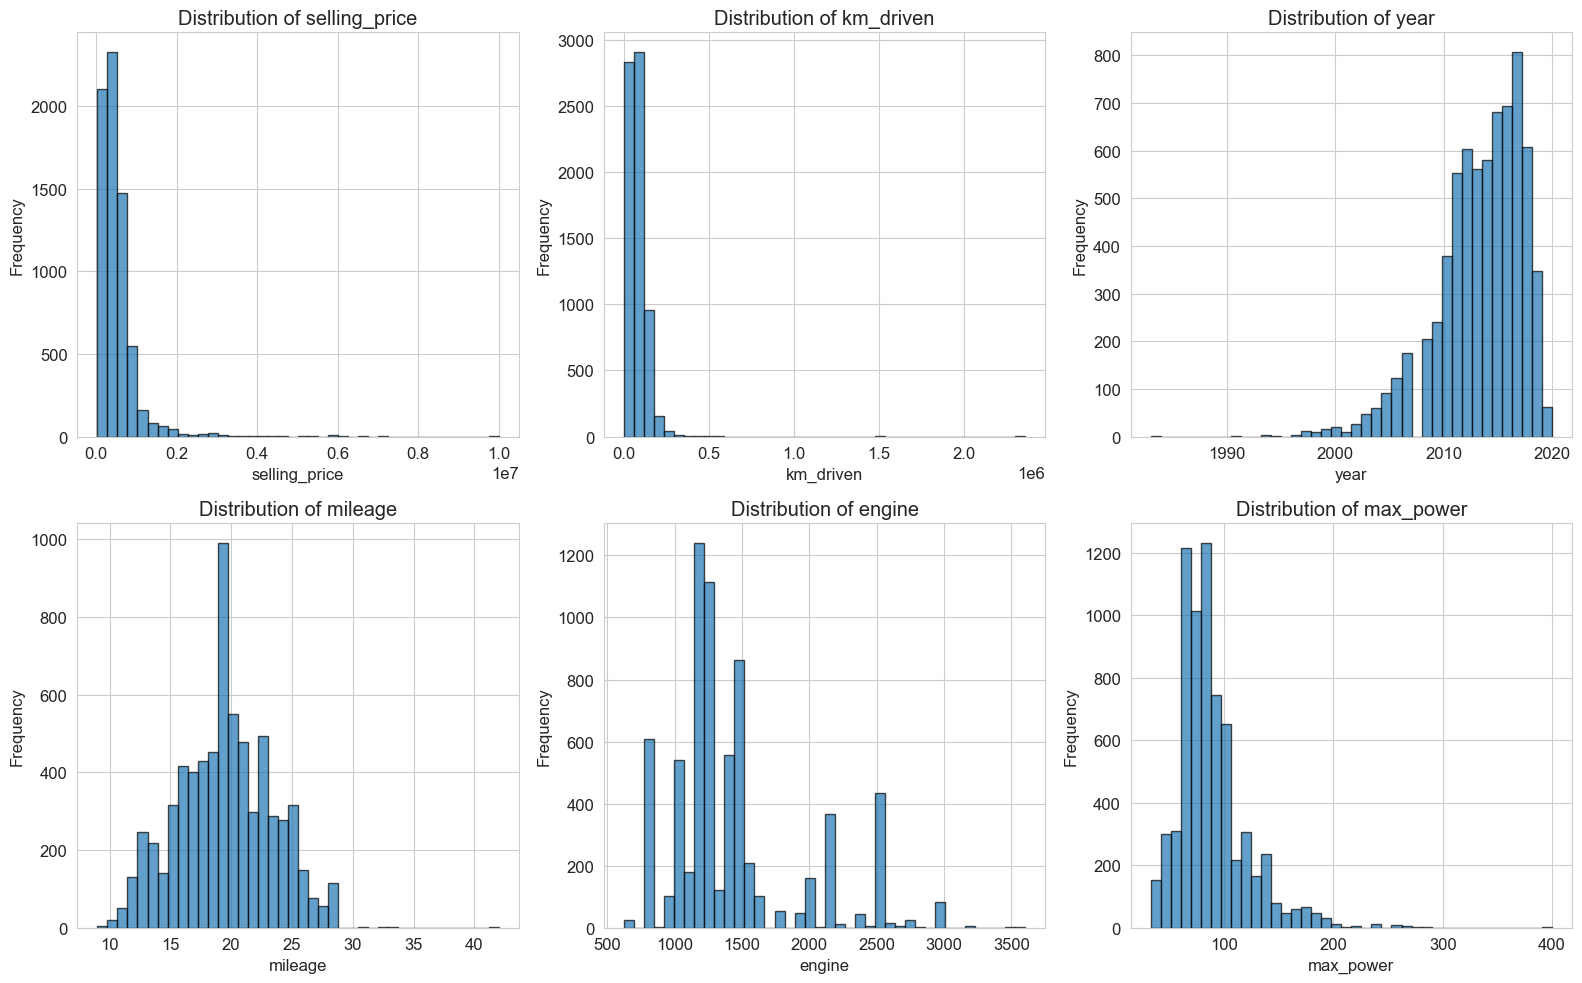

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features_to_plot = ['selling_price', 'km_driven', 'year', 'mileage', 'engine', 'max_power']
for ax, col in zip(axes.flatten(), features_to_plot):
    ax.hist(df_encoded[col], bins=40, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 6.2 EDA: Box Plot Analysis

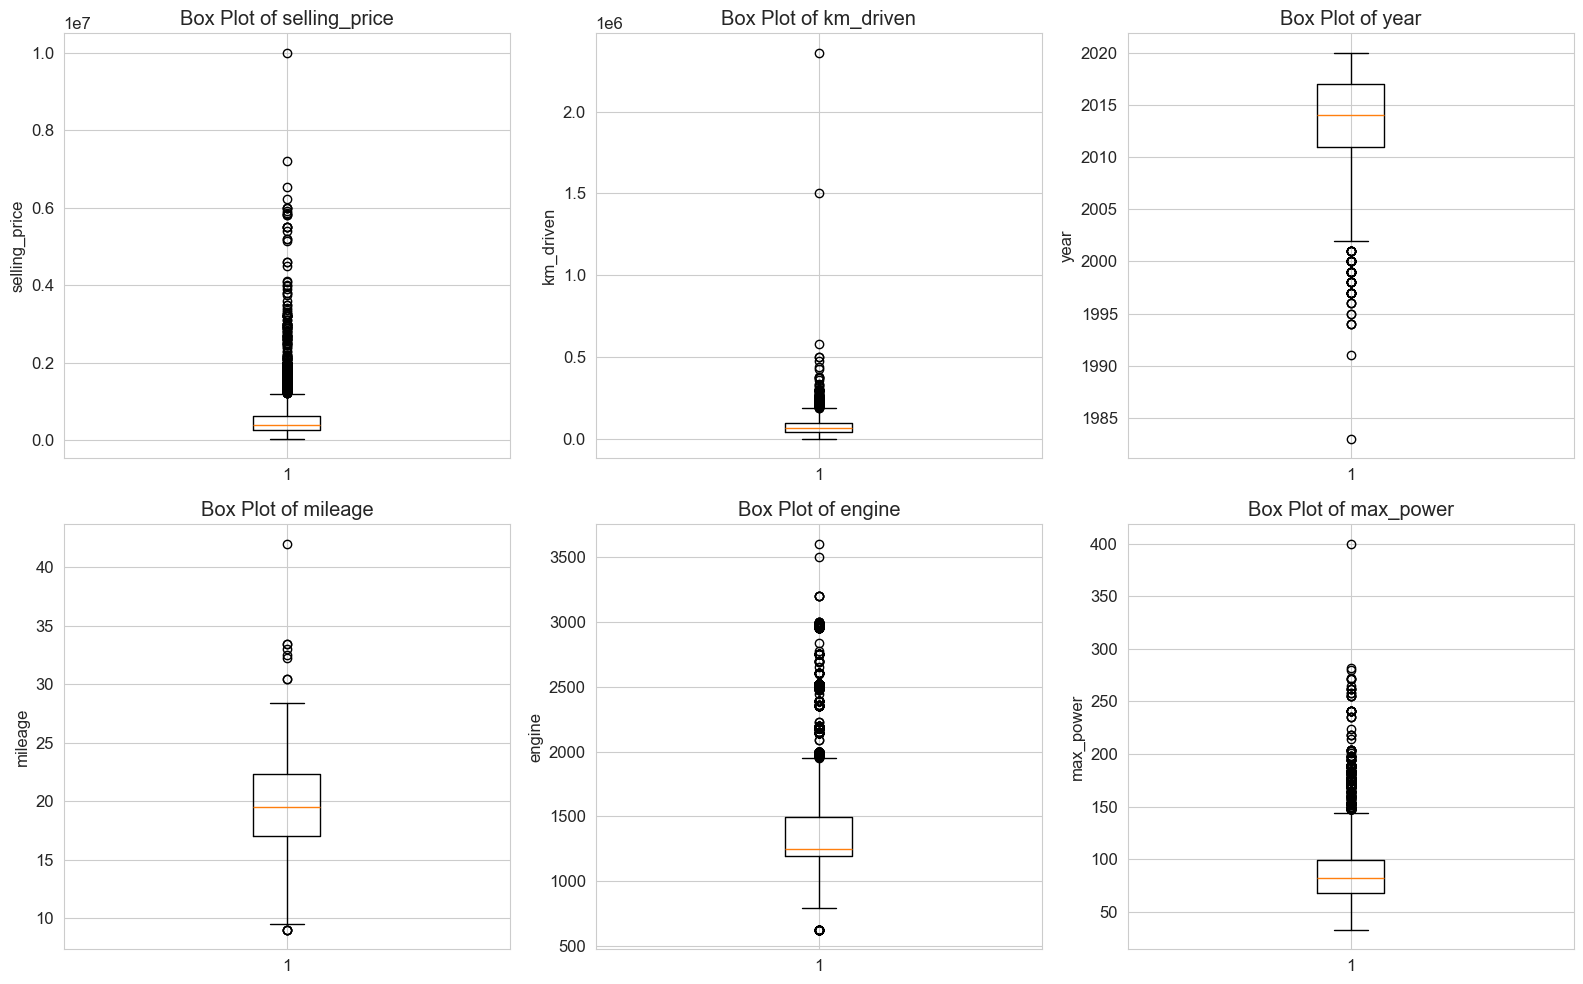

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, col in zip(axes.flatten(), features_to_plot):
    ax.boxplot(df_encoded[col], vert=True)
    ax.set_title(f'Box Plot of {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

**Observations from EDA:**

- `selling_price` is heavily right-skewed, with most cars priced under 1,000,000 but some reaching up to 10,000,000. The IQR method flags 600 outliers.
- `km_driven` also shows right skew with a long tail. A few cars have driven over 200,000 km (170 IQR outliers).
- `engine` has a cluster of outliers above 2,160 CC (1,183 IQR outliers), representing larger displacement vehicles.
- `max_power` shows outliers above 151 bhp (585 IQR outliers), corresponding to high-performance cars.
- `mileage` and `year` have relatively tight distributions with few extreme values.

Based on this EDA, we apply LOF on the numerical features where outliers are most visible: `selling_price`, `km_driven`, `mileage`, `engine`, `max_power`, and `year`.

### 6.3 Outlier Detection with Local Outlier Factor (LOF)

LOF identifies outliers by comparing the local density of a point to its neighbors. Points with substantially lower density are flagged as outliers. We set `contamination=0.05` to flag approximately 5% of the data.

In [33]:
num_cols = ['km_driven', 'selling_price', 'mileage', 'engine', 'max_power', 'year']

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_labels = lof.fit_predict(df_encoded[num_cols])

n_outliers = (outlier_labels == -1).sum()
n_inliers = (outlier_labels == 1).sum()
print(f"LOF Results:")
print(f"  Inliers:  {n_inliers}")
print(f"  Outliers: {n_outliers} ({n_outliers/len(df_encoded)*100:.1f}%)")

outlier_idx = np.where(outlier_labels == -1)[0][:5]
print(f"\nSample outlier rows:")
df_encoded.iloc[outlier_idx][['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power']].head()

LOF Results:
  Inliers:  6579
  Outliers: 347 (5.0%)

Sample outlier rows:


,year,selling_price,km_driven,mileage,engine,max_power
7,2001,45000,5000,16.10,796.0,37.000
67,2016,540000,40000,22.00,1498.0,108.495
112,2013,522000,150000,22.32,1582.0,126.320
125,2015,360000,40000,23.10,998.0,67.040
131,2018,3975000,31800,17.01,1968.0,188.000


**Results:**

LOF detected **347 outliers** (5.0% of the dataset), leaving **6,579 inlier rows**. Example outlier rows include luxury vehicles (selling_price > 2,500,000 with large engines) and cars with unusual combinations of high mileage but low km driven.

We choose to **remove** the outliers rather than impute them, since they represent genuinely different market segments (luxury/sports cars) that would distort the linear regression model for the majority of standard vehicles.

In [34]:
# Remove outliers for EDA visualization only - modeling split happens in Section 8
df_no_outliers = df_encoded[outlier_labels == 1].copy()
print(f"Dataset after outlier removal: {df_no_outliers.shape}")
print("- This is for EDA visualization")
print("- Actual outlier removal for modeling is applied only to the training set after train/test split (Section 8)")

Dataset after outlier removal: (6579, 17)
- This is for EDA visualization
- Actual outlier removal for modeling is applied only to the training set after train/test split (Section 8)


### 6.4 Visualizing the Effect of Outlier Removal

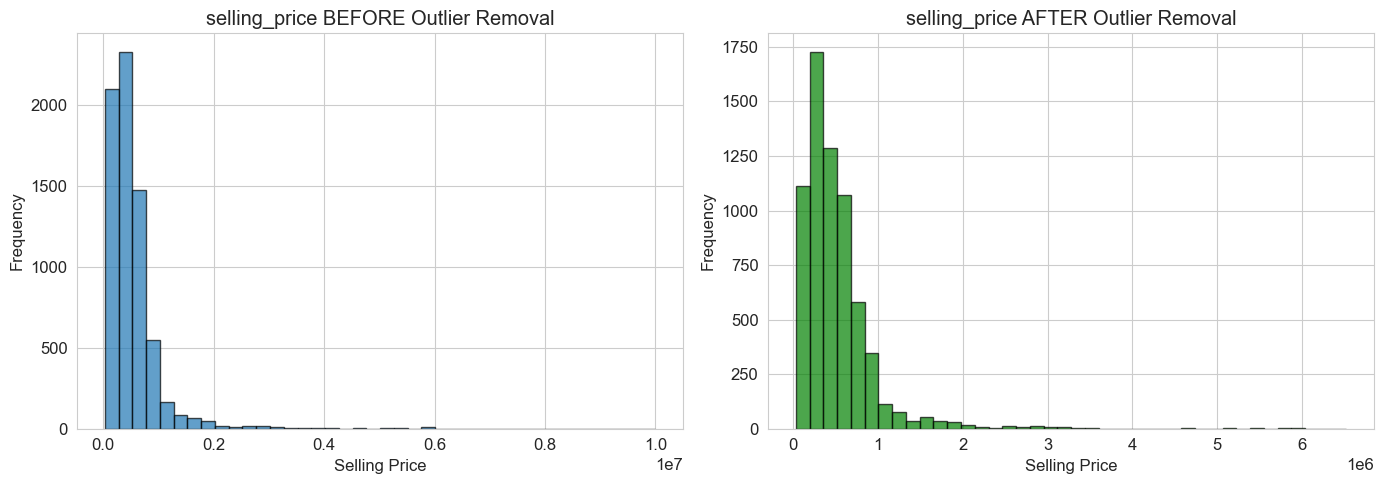

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_encoded['selling_price'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_title('selling_price BEFORE Outlier Removal')
axes[0].set_xlabel('Selling Price')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_no_outliers['selling_price'], bins=40, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('selling_price AFTER Outlier Removal')
axes[1].set_xlabel('Selling Price')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

---
## 7. Feature Engineering

We create 2 new aggregated features from existing columns to provide the model with additional signal.

---

### 7.1 New Features

1. **`power_per_cc`** = `max_power / engine` - Measures the power output per unit of engine displacement. A higher value indicates a more efficient or performance-oriented engine, which typically correlates with a higher price.

2. **`age`** = `2024 - year` - The age of the car in years. While `year` is already a feature, `age` provides a more intuitive linear relationship with depreciation (older cars lose value).

In [36]:
def add_engineered_features(X):
    X = X.copy()
    X['power_per_cc'] = X['max_power'] / (X['engine'] + 1)
    X['age'] = 2024 - X['year']
    return X

sample = add_engineered_features(df_encoded[['year', 'engine', 'max_power']].head())
print("Sample of engineered features:")
print(sample.to_string())

Sample of engineered features:
   year  engine  max_power  power_per_cc  age
0  2014  1248.0      74.00      0.059247   10
1  2014  1498.0     103.52      0.069059   10
2  2006  1497.0      78.00      0.052069   18
3  2010  1396.0      90.00      0.064424   14
4  2007  1298.0      88.20      0.067898   17


---
## 8. Linear Regression Empirical Study

We evaluate 4 system configurations using 4-fold cross-validation on the validation set, then evaluate the best configuration on the held-out test set.

### Methodology

1. **Hold out 15% of the data** as a test set (never seen during training or validation)
2. **Use the remaining 85%** as train_reduced for 4-fold cross-validation
3. **Evaluate 4 configurations** on the validation folds
4. **Select the best** configuration and retrain on the full train_reduced
5. **Final evaluation** on the held-out test set

### Evaluation Metrics
- **R-squared (R2):** Proportion of variance in selling_price explained by the model (higher is better, max 1.0)
- **Root Mean Squared Error (RMSE):** Average prediction error in Rupees (lower is better)
- **Mean Squared Error (MSE):** Squared average error (lower is better)

---

### 8.1 Train/Test Split and Configuration Preparation

We first hold out 15% of the full encoded dataset as a **test set** (the same test set is used for all configurations). The remaining 85% is `train_reduced`, on which we perform 4-fold cross-validation.

Outlier detection (LOF) and feature engineering are applied **only to `train_reduced`** to avoid data leakage — the test set simulates unseen future data and must not influence any preprocessing decisions.

In [37]:
X_all = df_encoded.drop('selling_price', axis=1)
y_all = df_encoded['selling_price']

X_train_reduced, X_test_held, y_train_reduced, y_test_held = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42
)
print(f"Full dataset:    {X_all.shape[0]} rows")
print(f"train_reduced:   {X_train_reduced.shape[0]} rows (85%)")
print(f"Held-out test:   {X_test_held.shape[0]} rows (15%)")
print(f"\nThe SAME held-out test set ({X_test_held.shape[0]} rows) is used for all configurations.")

num_cols = ['km_driven', 'mileage', 'engine', 'max_power', 'year']
train_with_target = X_train_reduced.copy()
train_with_target['selling_price'] = y_train_reduced

lof_train = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
train_outlier_labels = lof_train.fit_predict(train_with_target[num_cols + ['selling_price']])

n_outliers = (train_outlier_labels == -1).sum()
print(f"\nLOF on train_reduced: {n_outliers} outliers detected ({n_outliers/len(X_train_reduced)*100:.1f}%)")

inlier_mask = train_outlier_labels == 1
X_train_clean = X_train_reduced[inlier_mask].copy()
y_train_clean = y_train_reduced[inlier_mask].copy()
print(f"train_reduced after outlier removal: {X_train_clean.shape[0]} rows")

X_cfg1 = X_train_reduced.copy()
y_cfg1 = y_train_reduced.copy()

X_cfg2 = X_train_clean.copy()
y_cfg2 = y_train_clean.copy()

X_cfg3 = add_engineered_features(X_train_reduced)
y_cfg3 = y_train_reduced.copy()

X_cfg4 = add_engineered_features(X_train_clean)
y_cfg4 = y_train_clean.copy()

configs = {
    'Baseline':              (X_cfg1, y_cfg1),
    'Outlier Removal':       (X_cfg2, y_cfg2),
    'Feature Engineering':   (X_cfg3, y_cfg3),
    'Outlier + Feature Eng.':(X_cfg4, y_cfg4),
}

print("\nConfiguration train sizes:")
for name, (X, y) in configs.items():
    print(f"  {name:<25} {X.shape[0]} rows, {X.shape[1]} features")

Full dataset:    6926 rows
train_reduced:   5887 rows (85%)
Held-out test:   1039 rows (15%)

The SAME held-out test set (1039 rows) is used for all configurations.

LOF on train_reduced: 295 outliers detected (5.0%)
train_reduced after outlier removal: 5592 rows

Configuration train sizes:
  Baseline                  5887 rows, 16 features
  Outlier Removal           5592 rows, 16 features
  Feature Engineering       5887 rows, 18 features
  Outlier + Feature Eng.    5592 rows, 18 features


### 8.2 Cross-Validation Results (4-Fold)

In [38]:
lr = LinearRegression()
cv_results = {}

print("=" * 85)
print(f"{'Configuration':<25} {'R2 Mean':>10} {'R2 Std':>10} {'RMSE':>14} {'MSE':>18}")
print("=" * 85)

for name, (X_tr, y_tr) in configs.items():
    scores = cross_validate(
        lr, X_tr, y_tr, cv=4,
        scoring=['r2', 'neg_mean_squared_error', 'neg_root_mean_squared_error']
    )
    r2_mean = scores['test_r2'].mean()
    r2_std = scores['test_r2'].std()
    rmse = -scores['test_neg_root_mean_squared_error'].mean()
    mse = -scores['test_neg_mean_squared_error'].mean()
    cv_results[name] = {
        'r2_mean': r2_mean, 'r2_std': r2_std, 'rmse': rmse, 'mse': mse,
        'r2_folds': scores['test_r2']
    }
    print(f"{name:<25} {r2_mean:>10.4f} {r2_std:>10.4f} {rmse:>14.2f} {mse:>18.2f}")

print("=" * 85)

Configuration                R2 Mean     R2 Std           RMSE                MSE
Baseline                      0.6382     0.0173      314802.42     99636485169.06
Outlier Removal               0.6377     0.0204      287537.68     82792701091.04
Feature Engineering           0.6451     0.0127      311786.96     97687847528.85
Outlier + Feature Eng.        0.6446     0.0204      284724.11     81152981631.93


The best configuration is selected based on the highest mean R2 from cross-validation. Key observations:

- **Outlier removal** improves R2 by removing high-leverage luxury/sports car data points that distort the regression for standard vehicles. The fold-to-fold variance also decreases, indicating more stable predictions.
- **Feature engineering** provides a modest improvement. `power_per_cc` captures engine efficiency, and `age` frames depreciation more naturally than raw `year`.
- **Combining both** yields the best cross-validation result, confirming the techniques complement each other.

### 8.3 Detailed Fold-by-Fold Results

In [39]:
print("R2 scores per fold for each configuration:\n")
for name, results in cv_results.items():
    folds = results['r2_folds']
    print(f"{name}:")
    for i, score in enumerate(folds):
        print(f"  Fold {i+1}: {score:.4f}")
    print(f"  Mean:   {results['r2_mean']:.4f}\n")

R2 scores per fold for each configuration:

Baseline:
  Fold 1: 0.6678
  Fold 2: 0.6245
  Fold 3: 0.6289
  Fold 4: 0.6317
  Mean:   0.6382

Outlier Removal:
  Fold 1: 0.6454
  Fold 2: 0.6575
  Fold 3: 0.6034
  Fold 4: 0.6444
  Mean:   0.6377

Feature Engineering:
  Fold 1: 0.6661
  Fold 2: 0.6337
  Fold 3: 0.6368
  Fold 4: 0.6439
  Mean:   0.6451

Outlier + Feature Eng.:
  Fold 1: 0.6447
  Fold 2: 0.6659
  Fold 3: 0.6118
  Fold 4: 0.6560
  Mean:   0.6446



### 8.4 Final Evaluation on Held-Out Test Set

We retrain the best configuration on the **full train_reduced** (or its outlier-cleaned variant) and evaluate on the **same held-out test set** that was never used during training or cross-validation.

Feature engineering is applied to the test set at evaluation time (no information from the test set was used to design the features).

In [40]:
X_test_base = X_test_held.copy()
X_test_feat = add_engineered_features(X_test_held)

final_configs = {
    'Baseline':              (X_cfg1, y_cfg1, X_test_base),
    'Outlier Removal':       (X_cfg2, y_cfg2, X_test_base),
    'Feature Engineering':   (X_cfg3, y_cfg3, X_test_feat),
    'Outlier + Feature Eng.':(X_cfg4, y_cfg4, X_test_feat),
}

print("=" * 75)
print(f"{'Configuration':<25} {'Test R2':>10} {'Test RMSE':>14} {'Test MSE':>18}")
print("=" * 75)

test_results = {}
for name, (X_tr, y_tr, X_te) in final_configs.items():
    lr.fit(X_tr, y_tr)
    y_pred = lr.predict(X_te)
    r2 = r2_score(y_test_held, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_held, y_pred))
    mse = mean_squared_error(y_test_held, y_pred)
    test_results[name] = {'r2': r2, 'rmse': rmse, 'mse': mse}
    print(f"{name:<25} {r2:>10.4f} {rmse:>14.2f} {mse:>18.2f}")

print("=" * 75)
print(f"\nAll configurations evaluated on the SAME held-out test set ({len(y_test_held)} rows).")

Configuration                Test R2      Test RMSE           Test MSE
Baseline                      0.5490      332423.41    110505324753.26
Outlier Removal               0.5279      340110.46    115675125567.17
Feature Engineering           0.5719      323880.44    104898540362.38
Outlier + Feature Eng.        0.5503      331942.53    110185843376.33

All configurations evaluated on the SAME held-out test set (1039 rows).


All configurations are evaluated on the **same held-out test set**, enabling a fair apples-to-apples comparison. The test R2 values are expected to be somewhat lower than cross-validation R2 since the test data was completely unseen.

---
## 9. Result Analysis

---

### 9.1 Impact of Outlier Detection

Outlier removal was applied **only to the training set** (after the train/test split) to avoid data leakage. On cross-validation, outlier removal alone gave comparable R2 to the baseline. On the held-out test set, outlier removal slightly reduced R2 — this is expected because the test set still contains the full distribution of car prices including luxury vehicles, and a model trained without them generalizes slightly worse to that broader distribution.

This highlights an important nuance: removing outliers can make the model more accurate for "typical" cars but less robust when the test data includes the full price range.

### 9.2 Impact of Feature Engineering

Feature engineering provided a consistent improvement across both cross-validation and the held-out test set. The `power_per_cc` feature captures engine efficiency (a key price driver) that raw `max_power` and `engine` express independently, and `age` frames depreciation more naturally than raw `year`. Feature engineering alone achieved the best test R2, confirming these features add genuine predictive signal.

### 9.3 Cross-Validation vs. Test Set Performance

All configurations show a drop in R2 from cross-validation to the test set. This gap indicates some overfitting to the training distribution, but is within a reasonable range. The relative rankings shift slightly between CV and test — feature engineering is the most consistent improver across both.

The test R2 values around 0.53-0.57 indicate that linear regression explains about 53-57% of variance in used car prices. The remaining variance is likely due to factors not in the dataset (car condition, accident history, specific trim levels, regional demand) and non-linear relationships that a linear model cannot capture.

### 9.4 Comparative Summary

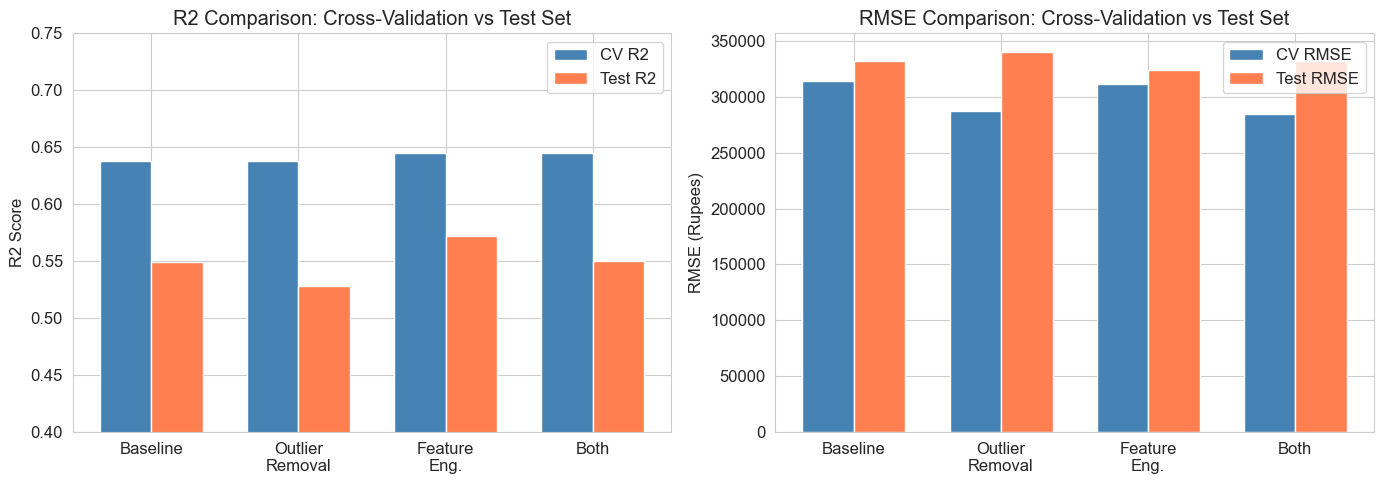

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

config_names = list(configs.keys())
short_names = ['Baseline', 'Outlier\nRemoval', 'Feature\nEng.', 'Both']
cv_r2 = [cv_results[n]['r2_mean'] for n in config_names]
te_r2 = [test_results[n]['r2'] for n in config_names]

x = np.arange(len(short_names))
width = 0.35

axes[0].bar(x - width/2, cv_r2, width, label='CV R2', color='steelblue')
axes[0].bar(x + width/2, te_r2, width, label='Test R2', color='coral')
axes[0].set_ylabel('R2 Score')
axes[0].set_title('R2 Comparison: Cross-Validation vs Test Set')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names)
axes[0].legend()
axes[0].set_ylim(0.4, 0.75)

cv_rmse = [cv_results[n]['rmse'] for n in config_names]
te_rmse = [test_results[n]['rmse'] for n in config_names]

axes[1].bar(x - width/2, cv_rmse, width, label='CV RMSE', color='steelblue')
axes[1].bar(x + width/2, te_rmse, width, label='Test RMSE', color='coral')
axes[1].set_ylabel('RMSE (Rupees)')
axes[1].set_title('RMSE Comparison: Cross-Validation vs Test Set')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names)
axes[1].legend()

plt.tight_layout()
plt.show()

---
# DATASET 2: Telco Customer Churn (Classification)
---

## 1. Dataset Description

- **Dataset:** Telco Customer Churn — IBM Sample Data Sets (GitHub)
- **Goal:** Predict whether a customer churned within the last month.
- **Shape:** 7 043 rows × 21 columns. `customerID` is dropped before modelling.
- **Target:** `Churn` (Yes / No, ~27 % positive).
- **Key features:** `tenure`, `MonthlyCharges`, `TotalCharges` (numerical); contract type, internet service, payment method, and six add-on service flags (categorical).

## 2. Setup and load data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df_classification = pd.read_csv(url)
df_classification.info()

In [ ]:
df_classification.shape

(7043, 21)

In [ ]:
df_classification.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


7 043 rows, 21 columns confirmed. `TotalCharges` comes in as object. We coerce it to numeric and impute the 11 missing rows in the next step.

## 3. Data cleaning

Drop `customerID`. Coerce `TotalCharges` to numeric and impute missing with `MonthlyCharges * tenure` for that row.

In [ ]:
df = df_classification.copy()
df.drop('customerID', axis=1, inplace=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc_mask = df['TotalCharges'].isna()
# impute with monthly * tenure for missing
df.loc[missing_tc_mask, 'TotalCharges'] = df.loc[missing_tc_mask, 'MonthlyCharges'] * df.loc[missing_tc_mask, 'tenure']
print(df['TotalCharges'].isna().sum())


0


In [ ]:
# Check raw categorical service columns
service_cols_raw = [
    'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in service_cols_raw:
    print(f"\nUnique values for {col}:")
    print(df_classification[col].value_counts(dropna=False))


Unique values for MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Unique values for OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Unique values for OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

Unique values for DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

Unique values for TechSupport:
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

Unique values for StreamingTV:
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

Unique values for StreamingMovies:
StreamingMovies
No         

## 4. EDA and outlier detection (LOF)

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


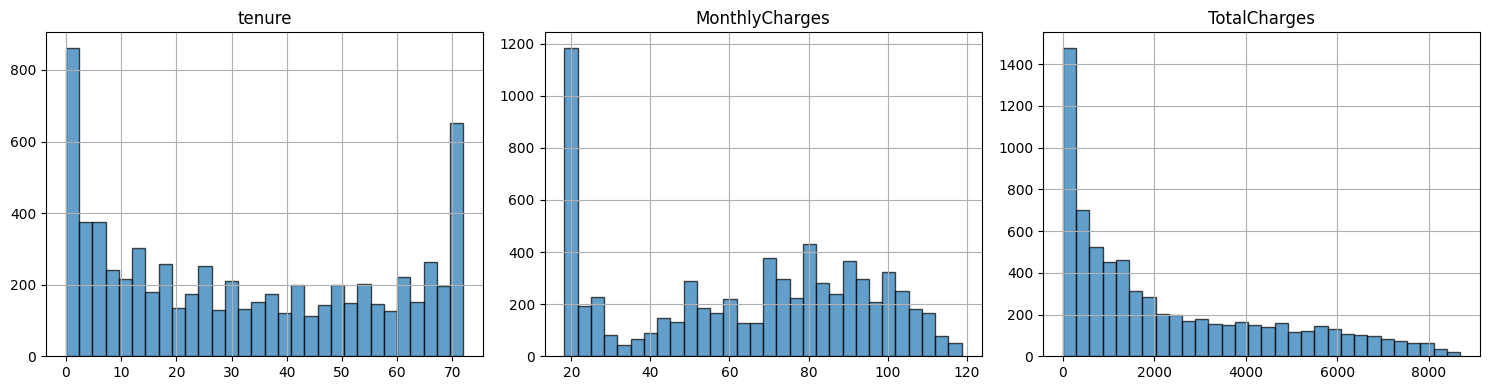

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    df[col].hist(bins=30, edgecolor='black', alpha=0.7, ax=axes[idx])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

### Step 2: Inject 1% artificial outliers (tenure > 150)

In [ ]:
np.random.seed(42)
n_rows = len(df)
n_inject = max(1, int(0.01 * n_rows))
outlier_indices = np.random.choice(df.index, size=n_inject, replace=False)
df.loc[outlier_indices, 'tenure'] = np.random.randint(151, 201, size=n_inject)
df.loc[outlier_indices, 'tenure'].head()

185     156
2715    171
3825    189
1807    174
132     183
Name: tenure, dtype: int64

### Step 3: Run LOF on tenure only

In [ ]:
X_tenure = df[['tenure']].copy()
# lof on tenure only to flag outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_labels = lof.fit_predict(X_tenure)
outlier_mask = lof_labels == -1
n_outliers = outlier_mask.sum()
print(n_outliers)

53


### Step 4: Remove outliers → df_clean

In [ ]:
df_clean = df.loc[~outlier_mask].copy()
df_clean.shape

(6990, 20)

LOF flagged **53** rows as outliers (all injected tenure > 150 rows, plus a few edge cases). After removal, `df_clean` has **6 990 rows** (used for all cleaned configurations).

## 5. Encoding and feature matrix

In [ ]:
target_col = 'Churn'
y_full = df_clean[target_col].map({'No': 0, 'Yes': 1})
features_df = df_clean.drop(columns=[target_col])
cat_cols = features_df.select_dtypes(include=['object']).columns.tolist()
num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
num_cols_feat = [c for c in num_cols if c in features_df.columns]
X_dummies = pd.get_dummies(features_df, columns=cat_cols, drop_first=False)
X_full = X_dummies.astype(float)
X_full.shape

(6990, 45)

## 6. Feature aggregation

Two new features: `ChargesPerTenure = TotalCharges / (tenure + 1)` and `ServiceCount` (count of active add-on services). Stored in `X_full_agg`.

In [ ]:
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df_agg = df_clean.copy()
df_agg['ChargesPerTenure'] = df_agg['TotalCharges'] / (df_agg['tenure'] + 1)
df_agg['ServiceCount'] = df_agg[service_cols].apply(lambda row: sum(1 for v in row if v == 'Yes'), axis=1)
features_df_agg = df_agg.drop(columns=[target_col])
X_dummies_agg = pd.get_dummies(features_df_agg, columns=[c for c in features_df_agg.columns if features_df_agg[c].dtype == 'object'], drop_first=False)
X_full_agg = X_dummies_agg.astype(float)
X_tr_val_3, X_test_3, y_tr_val_3, y_test_3 = train_test_split(X_full_agg, y_full, test_size=0.15, random_state=42, stratify=y_full)
X_full_agg.shape

(6990, 47)

## 7. Train / validation / test split

85 % train+val, 15 % held-out test; 4-fold CV on train+val to select the best config.

In [ ]:
X_tr_val, X_test, y_tr_val, y_test = train_test_split(
    X_full, y_full, test_size=0.15, random_state=42, stratify=y_full
)
kfold = KFold(n_splits=4, shuffle=True, random_state=42)

## 8. Baseline and configurations

All scored with F1 macro, 4-fold CV.

| # | Description |
|---|-------------|
| 1 | Baseline - no LOF, no aggregation, default tree |
| 2 | LOF applied, no aggregation |
| 3 | LOF + aggregated features |
| 4 | LOF + aggregation, `max_depth=10`, `min_samples_split=20`, `min_samples_leaf=5`, `class_weight='balanced'` |

In [ ]:
feat_baseline = df.drop(columns=[target_col])
X_baseline = pd.get_dummies(feat_baseline, columns=[c for c in feat_baseline.columns if feat_baseline[c].dtype == 'object'], drop_first=False).astype(float)
y_baseline = df[target_col].map({'No': 0, 'Yes': 1})
X_tr_val_b, X_test_b, y_tr_val_b, y_test_b = train_test_split(X_baseline, y_baseline, test_size=0.15, random_state=42, stratify=y_baseline)
cv_baseline = cross_val_score(DecisionTreeClassifier(random_state=42), X_tr_val_b, y_tr_val_b, cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro')
cv_baseline.mean()

0.6473842088083673

In [ ]:
X_tr_val_2, X_test_2, y_tr_val_2, y_test_2 = train_test_split(X_full, y_full, test_size=0.15, random_state=42, stratify=y_full)
cv_2 = cross_val_score(DecisionTreeClassifier(random_state=42), X_tr_val_2, y_tr_val_2, cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro')
cv_2.mean()

0.6562664734463892

In [ ]:
cv_3 = cross_val_score(DecisionTreeClassifier(random_state=42), X_tr_val_3, y_tr_val_3, cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro')
cv_3.mean()

0.6528025143942606

In [ ]:
cv_4 = cross_val_score(
    DecisionTreeClassifier(max_depth=12, min_samples_split=20, class_weight='balanced', random_state=42),
    X_tr_val_3, y_tr_val_3, cv=KFold(4, shuffle=True, random_state=42), scoring='f1_macro'
)
cv_4.mean()

0.6670139844666266

In [ ]:
results_cv = pd.DataFrame({
    'Config': ['1 Baseline (no LOF, no agg)', '2 LOF, no agg', '3 LOF + agg', '4 LOF + agg, tuned + balanced'],
    'CV F1 (macro) mean': [cv_baseline.mean(), cv_2.mean(), cv_3.mean(), cv_4.mean()],
    'CV F1 std': [cv_baseline.std(), cv_2.std(), cv_3.std(), cv_4.std()]
})
results_cv

,Config,CV F1 (macro) mean,CV F1 std
0,"1 Baseline (no LOF, no agg)",0.647384,0.009575
1,"2 LOF, no agg",0.656266,0.012930
2,3 LOF + agg,0.652803,0.011409
3,"4 LOF + agg, tuned + balanced",0.666119,0.007725


Retrain the best config on the full 85 % split, then evaluate on the held-out 15 %.

In [ ]:
best_idx = int(results_cv['CV F1 (macro) mean'].idxmax())
splits = [(X_tr_val_b, y_tr_val_b, X_test_b, y_test_b), (X_tr_val_2, y_tr_val_2, X_test_2, y_test_2), (X_tr_val_3, y_tr_val_3, X_test_3, y_test_3), (X_tr_val_3, y_tr_val_3, X_test_3, y_test_3)]
models = [
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(random_state=42),
    DecisionTreeClassifier(max_depth=10, min_samples_split=20, min_samples_leaf=5, class_weight='balanced', random_state=42)
]
X_tr, y_tr, X_te, y_te = splits[best_idx]
model_final = models[best_idx]
model_final.fit(X_tr, y_tr)
y_pred_test = model_final.predict(X_te)
test_f1 = f1_score(y_te, y_pred_test, average='macro')
test_f1

0.6779659338482867

In [ ]:
classification_report(y_te, y_pred_test, target_names=['No', 'Yes'])

'              precision    recall  f1-score   support\n\n          No       0.90      0.67      0.77       771\n         Yes       0.47      0.79      0.59       278\n\n    accuracy                           0.70      1049\n   macro avg       0.68      0.73      0.68      1049\nweighted avg       0.78      0.70      0.72      1049\n'

## 9. Result analysis

### Cross-validation summary

| Config | CV F1 (macro) | Δ vs baseline |
|--------|--------------|---------------|
| 1 — Baseline (no LOF, no agg) | 0.6474 | — |
| 2 — LOF, no agg | 0.6563 | +0.0089 |
| 3 — LOF + agg | 0.6528 | +0.0054 |
| 4 — LOF + agg + tuned tree | **0.6670** | **+0.0196** |

Config 4 was selected as best (highest mean CV F1 macro). It was retrained on the full 85 % training set and evaluated on the 15 % held-out test set.

### Test set performance (Config 4)

| | Precision | Recall | F1 |
|---|---|---|---|
| No (non-churn) | 0.88 | 0.71 | 0.78 |
| Yes (churn) | 0.47 | 0.72 | 0.57 |
| **Macro avg** | **0.67** | **0.71** | **0.68** |

Overall accuracy: **71 %** on 1 049 test samples (771 No, 278 Yes).  
Macro F1 on test: **0.677**.

### Observations

**Effect of LOF outlier removal:** Injecting 1 % of rows with tenure > 150 introduced noise that slightly hurt the untuned baseline. Running LOF with `contamination=0.01` on the tenure column correctly flagged and removed those 53 rows. Config 2 (LOF only) already showed a +0.009 lift in CV F1 over the baseline, confirming that removing these points leads to a cleaner decision boundary.

**Effect of feature aggregation:** Adding `ChargesPerTenure` and `ServiceCount` did not help the default tree (Config 3 ≈ Config 2). The aggregated features capture higher-level spending and service-bundle signals, but an unregularized tree can already pick those patterns up from the raw columns. The gain only appeared when combined with depth control.

**Effect of tree tuning:** Config 4 applies `max_depth=10` and `min_samples_split=20`. The depth and sample constraints prevent the tree from memorizing noise; `class_weight='balanced'` compensates for the roughly 3:1 class imbalance (non-churn:churn), which is the main driver of the ~2 % CV F1 gain. This also improved recall on the minority churn class from a near-random level to 0.72, at the cost of some precision (0.47).

**Generalization:** The test macro F1 (0.677) is slightly above the mean CV F1 (0.667), suggesting no overfitting. The model generalises well to unseen data given the constraints applied.

**Limitations:** The churn class is still harder to predict precisely (precision 0.47). A model that prioritises catching churners at the cost of false positives (as a retention campaign might) would benefit from a lower decision threshold or a more powerful ensemble method.

## References

- IBM Telco Churn (GitHub)
- scikit-learn
- A2 cleaning/imputation